## Imports and project paths


In [1]:

from pathlib import Path
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "2"
from sklearn.base import clone
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score, accuracy_score,f1_score

ROOT = Path.cwd()
CSV_PATH = ROOT / "data" / "instagram_data.csv"
IMAGE_DIR = ROOT / "data" / "insta_data"
RESULTS_DIR = ROOT / "results"
RESULTS_DIR.mkdir(exist_ok=True)
SEED = 42
N_CLUSTERS = 9      # Grouping CLIP image features into nine visual clusters


## Loading and Inspecting the Dataset

In [2]:
# Reading the Data

df = pd.read_csv(CSV_PATH)
print("Rows and columns:", df.shape)
print(df.head().to_string(index=False))


Rows and columns: (3785, 5)
 likes  no_of_comments          t  follower_count_at_t               image_path
154552               0 1594174009             40934474 ../Data/insta_data/0.jpg
 97386               0 1593571666             40934474 ../Data/insta_data/2.jpg
145632               0 1593136341             40934474 ../Data/insta_data/4.jpg
 76461               0 1592981047             40934474 ../Data/insta_data/6.jpg
174620               0 1592703461             40934474 ../Data/insta_data/8.jpg


In [3]:
# Checking missing values and repeated rows

df.info()
print("\nMissing values:")
print(df.isna().sum())
print("\nRepeated full rows:", df.duplicated().sum())
print("Repeated image paths:", df["image_path"].duplicated().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3785 entries, 0 to 3784
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   likes                3785 non-null   int64 
 1   no_of_comments       3785 non-null   int64 
 2   t                    3785 non-null   int64 
 3   follower_count_at_t  3785 non-null   int64 
 4   image_path           3785 non-null   object
dtypes: int64(4), object(1)
memory usage: 148.0+ KB

Missing values:
likes                  0
no_of_comments         0
t                      0
follower_count_at_t    0
image_path             0
dtype: int64

Repeated full rows: 0
Repeated image paths: 0


In [4]:
# Checking for negative counts, zeros and unusually large values

count_columns = ["likes", "no_of_comments", "follower_count_at_t"]


print("Number of Negative counts:")
print((df[count_columns] < 0).sum())
print("\nNumber of Zero counts:")
print((df[count_columns] == 0).sum())
print("\nSummary:")
print(df[count_columns].describe().round(1).to_string())

required = ["likes", "follower_count_at_t", "t", "image_path"]
if df[required].isna().any().any():
    raise ValueError("Missing required metadata")
if (df[["likes", "follower_count_at_t"]] < 0).any().any():
    raise ValueError("Negative counts found")
if not np.isfinite(df[["likes", "follower_count_at_t", "t"]].to_numpy()).all():
    raise ValueError("The required numeric values should be finite")


Number of Negative counts:
likes                  0
no_of_comments         0
follower_count_at_t    0
dtype: int64

Number of Zero counts:
likes                   0
no_of_comments         62
follower_count_at_t     0
dtype: int64

Summary:
           likes  no_of_comments  follower_count_at_t
count     3785.0          3785.0               3785.0
mean    183253.6          2531.4           14094850.6
std     193696.9         21064.1            9402604.7
min       1431.0             0.0                187.0
25%      52087.0           194.0            7296298.0
50%     123664.0           484.0           11049698.0
75%     243144.0          1337.0           18362917.0
max    2161369.0        733973.0           40934474.0


In [5]:
# Understanding the timestamp

# I have interpreted t as Unix seconds and UTC as a reference timezone and not necessarily the content creator's local time.

df["post_time"] = pd.to_datetime(df["t"], unit="s", utc=True)
print(df[["t", "post_time"]].head().to_string(index=False))
print("\nEarliest post:", df["post_time"].min())
print("Latest post:", df["post_time"].max())


         t                 post_time
1594174009 2020-07-08 02:06:49+00:00
1593571666 2020-07-01 02:47:46+00:00
1593136341 2020-06-26 01:52:21+00:00
1592981047 2020-06-24 06:44:07+00:00
1592703461 2020-06-21 01:37:41+00:00

Earliest post: 2017-03-15 03:00:08+00:00
Latest post: 2020-07-12 08:05:02+00:00


## Splitting the Dataset into Training, Validation and Testing data

In [6]:
# Segregating the Training, Validation and Testing Data in 60%, 20% and 20% Split

df = df.sort_values("t").reset_index(drop=True)

first_cut = df.loc[int(len(df) * 0.60), "t"]
second_cut = df.loc[int(len(df) * 0.80), "t"]
train_df = df[df["t"] < first_cut].copy()
validation_df = df[(df["t"] >= first_cut) & (df["t"] < second_cut)].copy()
test_df = df[df["t"] >= second_cut].copy()
print("Training posts:", len(train_df))
print("Validation posts:", len(validation_df))
print("Test posts:", len(test_df))


# Sorting posts from oldest to newest to simulate predicting for later posts

print("\nTraining ends:", train_df["post_time"].max())
print("Validation ends:", validation_df["post_time"].max())
print("Test starts:", test_df["post_time"].min())
if min(len(train_df), len(validation_df), len(test_df)) == 0:
    raise ValueError("A time split is empty so inspect the timestamps")


Training posts: 2271
Validation posts: 757
Test posts: 757

Training ends: 2020-05-27 11:29:34+00:00
Validation ends: 2020-06-27 06:02:04+00:00
Test starts: 2020-06-27 06:02:25+00:00


## Exploratory Data Analysis

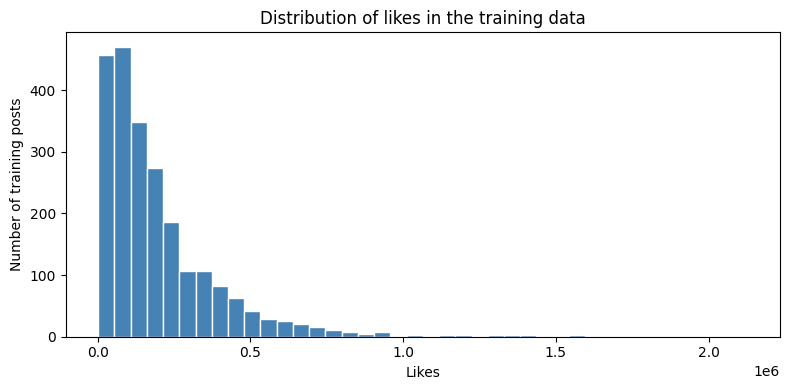

In [7]:
# Counting how many training posts fall into each range of likes 
# Cheking whether a few very popular posts make the distribution uneven


plt.figure(figsize=(8, 4))
plt.hist(train_df["likes"], bins=40, color="steelblue", edgecolor="white")
plt.xlabel("Likes")
plt.ylabel("Number of training posts")
plt.title("Distribution of likes in the training data")
plt.tight_layout()
plt.show()


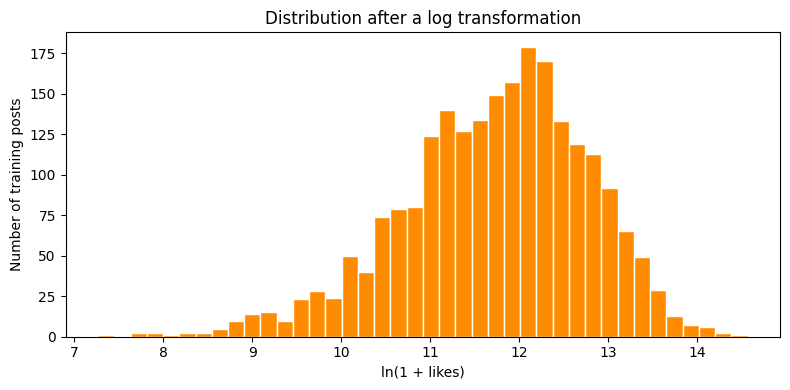

In [8]:
# Applying log1p to compress large like counts and make the distribution easier to inspect

train_df["log_likes"] = np.log1p(train_df["likes"])
plt.figure(figsize=(8, 4))
plt.hist(train_df["log_likes"], bins=40, color="darkorange", edgecolor="white")
plt.xlabel("ln(1 + likes)")
plt.ylabel("Number of training posts")
plt.title("Distribution after a log transformation")
plt.tight_layout()
plt.show()


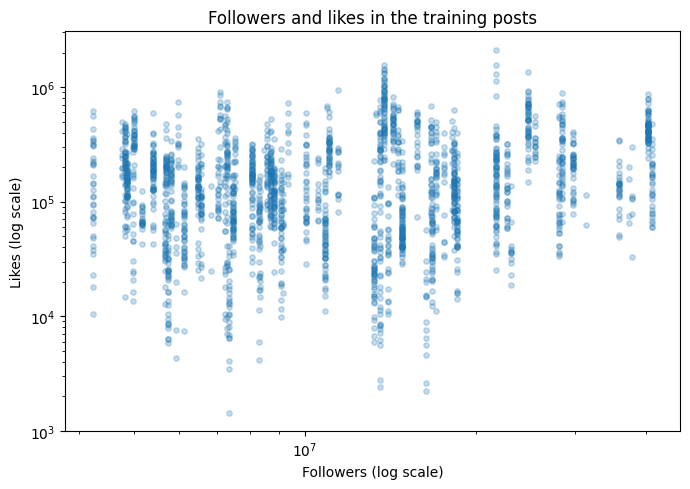

Spearman correlation: 0.147


In [9]:
# Plotting followers against likes to check whether larger audiences usually get more likes

positive_counts = (train_df["follower_count_at_t"] > 0) & (train_df["likes"] > 0)
plot_df = train_df[positive_counts]

plt.figure(figsize=(7, 5))
plt.scatter(plot_df["follower_count_at_t"], plot_df["likes"], alpha=0.25, s=15)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Followers (log scale)")
plt.ylabel("Likes (log scale)")
plt.title("Followers and likes in the training posts")
plt.tight_layout()
plt.show()

# Calculating Spearman correlation to measure how the two counts rank together


follower_rank = train_df["follower_count_at_t"].rank()
like_rank = train_df["likes"].rank()
correlation = follower_rank.corr(like_rank)
print("Spearman correlation:", round(correlation, 3))


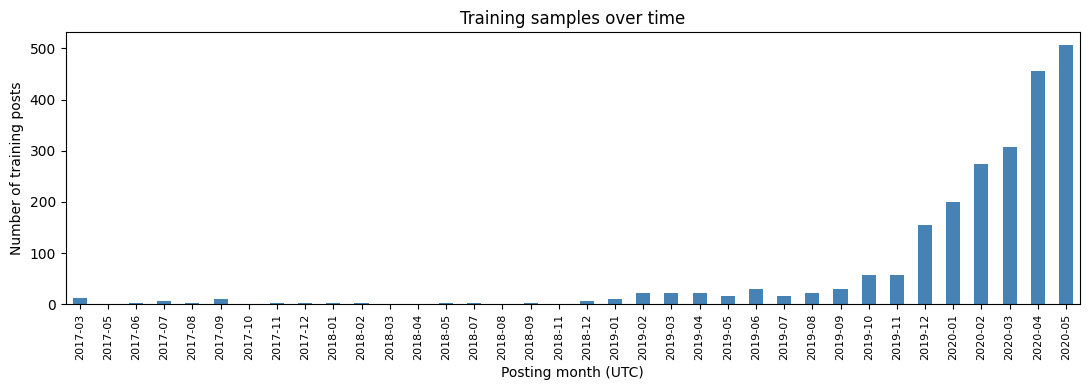

In [10]:
# Counting training posts by month to check the dataset's coverage over time

month = train_df["post_time"].dt.strftime("%Y-%m")
posts_per_month = month.value_counts().sort_index()

plt.figure(figsize=(11, 4))
posts_per_month.plot(kind="bar", color="steelblue")
plt.xlabel("Posting month (UTC)")
plt.ylabel("Number of training posts")
plt.title("Training samples over time")
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()


## Establishing Baseline and Simple Regression Models

In [11]:
# Predicting the training median for every validation post as a simple starting point.
# The median minimizes absolute error among constant predictions on the training data.
# Calculating Mean Absolute Error to see how much a trained model needs to improve.

from sklearn.metrics import mean_absolute_error


y_train = train_df["likes"]
y_validation = validation_df["likes"]

baseline_prediction = y_train.median()
baseline_predictions = np.full(len(y_validation), baseline_prediction)
baseline_mae = mean_absolute_error(y_validation, baseline_predictions)
print("Predict this number for every post:", baseline_prediction) # median of likes for training data
print("Validation posts Mean Absolute Error:", round(baseline_mae, 2))
results = [{"Model": "Median baseline", "Validation MAE": baseline_mae}]


Predict this number for every post: 137465.0
Validation posts Mean Absolute Error: 126160.22


In [12]:
# Fitting a straight-line relationship between followers and likes
# Comparing its validation MAE with the median baseline


from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor

X_train = train_df[["follower_count_at_t"]]
X_validation = validation_df[["follower_count_at_t"]]

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Replacing negative predictions with zero because like counts cannot be negative
linear_predictions = linear_model.predict(X_validation)
linear_predictions = np.maximum(linear_predictions, 0)
linear_mae = mean_absolute_error(y_validation, linear_predictions)
print("Slope:", linear_model.coef_[0])
print("Intercept:", linear_model.intercept_)
print("Validation posts MAE:", round(linear_mae, 2))
results.append({"Model": "Linear: raw followers, raw likes", "Validation MAE": linear_mae})

# Storing the model settings so the experiments can be repeated later
model_settings = {
    "Median baseline": {"model": DummyRegressor(strategy="median"), "columns": ["follower_count_at_t"], "log_target": False}, "Linear: raw followers, raw likes": {"model": linear_model, "columns": ["follower_count_at_t"], "log_target": False}
}


Slope: 0.004621857005155403
Intercept: 133244.10690280978
Validation posts MAE: 144999.21


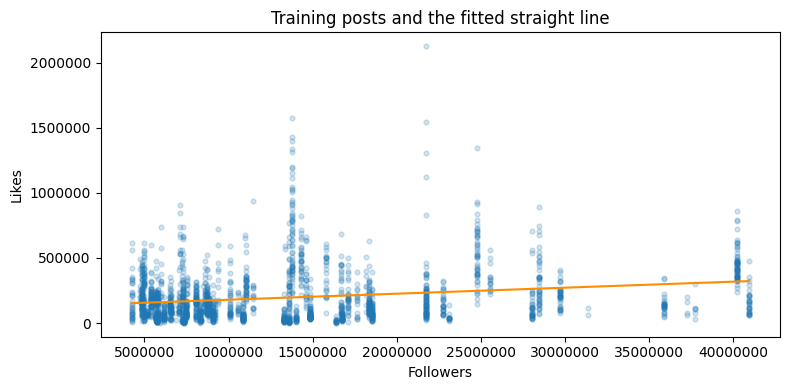

In [13]:
# Plotting the learned line alongside the training posts
# Checking how much individual posts differ from the followers-only prediction

sorted_followers = X_train.sort_values("follower_count_at_t")
fitted_line = linear_model.predict(sorted_followers)
plt.figure(figsize=(8, 4))
plt.scatter(X_train["follower_count_at_t"], y_train, alpha=0.2, s=12)
plt.plot(sorted_followers["follower_count_at_t"], fitted_line, color="darkorange")
plt.xlabel("Followers")
plt.ylabel("Likes")
plt.title("Training posts and the fitted straight line")
plt.ticklabel_format(axis="both", style="plain")
plt.tight_layout()
plt.show()


In [14]:
# Keeping the followers unchanged and training on log likes instead of raw likes
# This reduces the influence of very large counts during fitting

y_train_log = np.log1p(y_train)

log_target_model = LinearRegression()
log_target_model.fit(X_train, y_train_log)
validation_log_predictions = log_target_model.predict(X_validation)
log_model_predictions = np.maximum(np.expm1(validation_log_predictions), 0)
log_model_mae = mean_absolute_error(y_validation, log_model_predictions)
print("Validation MAE:", round(log_model_mae, 2))
results.append({"Model": "Linear Regression: raw followers, log likes", "Validation MAE": log_model_mae})
model_settings["Linear Regression: raw followers, log likes"] = {"model": log_target_model, "columns": ["follower_count_at_t"], "log_target": True}


print(pd.DataFrame(results).round(2).to_string(index=False))


Validation MAE: 125862.48
                                      Model  Validation MAE
                            Median baseline       126160.22
           Linear: raw followers, raw likes       144999.21
Linear Regression: raw followers, log likes       125862.48


In [15]:
# Transforming followers as well to test whether proportional changes are more useful
# Keeping the same rows and log target so only the input scale changes

df["log_followers"] = np.log1p(df["follower_count_at_t"])

X_train_log = df.loc[train_df.index, ["log_followers"]]
X_validation_log = df.loc[validation_df.index, ["log_followers"]]

log_both_model = LinearRegression()
log_both_model.fit(X_train_log, y_train_log)

log_both_predictions = np.maximum(np.expm1(log_both_model.predict(X_validation_log)), 0)
log_both_mae = mean_absolute_error(y_validation, log_both_predictions)

results.append({"Model": "Linear Regression: log followers, log likes", "Validation MAE": log_both_mae})
model_settings["Linear Regression: log followers, log likes"] = {"model": log_both_model, "columns": ["log_followers"], "log_target": True}
print(pd.DataFrame(results).round(2).to_string(index=False))


                                      Model  Validation MAE
                            Median baseline       126160.22
           Linear: raw followers, raw likes       144999.21
Linear Regression: raw followers, log likes       125862.48
Linear Regression: log followers, log likes       125338.32


## Evaluating Metadata Models

In [16]:
# Adding posting hour, weekday, month and time elapsed since the first training post

hour = df["post_time"].dt.hour
weekday = df["post_time"].dt.dayofweek
month = df["post_time"].dt.month - 1

# Using sine and cosine so neighbouring times, such as 23:00 and 00:00 stay close


df["hour_sine"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
df["weekday_sine"] = np.sin(2 * np.pi * weekday / 7)
df["weekday_cos"] = np.cos(2 * np.pi * weekday / 7)
df["month_sine"] = np.sin(2 * np.pi * month / 12)
df["month_cos"] = np.cos(2 * np.pi * month / 12)
time_origin = train_df["t"].min()
df["elapsed_years"] = (df["t"] - time_origin) / (365.25 * 24 * 60 * 60)

# Combining these features with log followers to create eight metadata inputs
# Excluding comments and actual likes because they would not be available before posting

feature_columns = ["log_followers", "hour_sine", "hour_cos", "weekday_sine", "weekday_cos", "month_sine", "month_cos", "elapsed_years"]

X_train_metadata = df.loc[train_df.index, feature_columns]
X_validation_metadata = df.loc[validation_df.index, feature_columns]
print(X_train_metadata.head().round(3).to_string(index=False))


 log_followers  hour_sine  hour_cos  weekday_sine  weekday_cos  month_sine  month_cos  elapsed_years
        16.734      0.707     0.707         0.975       -0.223       0.866        0.5          0.000
        16.734      0.966     0.259        -0.434       -0.901       0.866        0.5          0.006
        16.734      0.866    -0.500        -0.434       -0.901       0.866        0.5          0.006
        16.734      0.000     1.000        -0.782        0.623       0.866        0.5          0.011
        16.734      0.966    -0.259         0.975       -0.223       0.866        0.5          0.020


In [17]:
# Trying Ridge regression to limit very large coefficients
# Fitting feature scaling only on training data

from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


for alpha in [10, 100]:
    ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    ridge_model.fit(X_train_metadata, y_train_log)

    ridge_predictions = np.maximum(np.expm1(ridge_model.predict(X_validation_metadata)), 0)
    ridge_mae = mean_absolute_error(y_validation, ridge_predictions)
    name = "Metadata + Ridge alpha=" + str(alpha)

    results.append({"Model": name, "Validation MAE": ridge_mae})
    model_settings[name] = {"model": ridge_model, "columns": feature_columns, "log_target": True}

current_results = pd.DataFrame(results)
print(current_results[current_results["Model"].str.contains("Ridge")].round(2).to_string(index=False))


                     Model  Validation MAE
 Metadata + Ridge alpha=10       124494.65
Metadata + Ridge alpha=100       124453.81


In [18]:
# Trying a Random Forest to capture patterns that a straight line may miss
# Comparing two minimum leaf sizes to control how specific the trees can become
# Training on log likes and convert predictions back into counts before scoring

from sklearn.ensemble import RandomForestRegressor


for leaf_size in [5, 20]:
    forest_model = RandomForestRegressor(n_estimators=200, min_samples_leaf=leaf_size, random_state=42, n_jobs=2)
    forest_model.fit(X_train_metadata, y_train_log) 
    forest_predictions = np.maximum(np.expm1(forest_model.predict(X_validation_metadata)), 0)
    forest_mae = mean_absolute_error(y_validation, forest_predictions)
    name = "Metadata + forest leaf=" + str(leaf_size)

    results.append({"Model": name, "Validation MAE": forest_mae})
    model_settings[name] = {"model": forest_model, "columns": feature_columns, "log_target": True}

current_results = pd.DataFrame(results)
print(current_results[current_results["Model"].str.contains("forest")].round(2).to_string(index=False))


                    Model  Validation MAE
 Metadata + forest leaf=5       100325.46
Metadata + forest leaf=20       107441.72


                                      Model  Validation MAE
                   Metadata + forest leaf=5       100325.46
                  Metadata + forest leaf=20       107441.72
                 Metadata + Ridge alpha=100       124453.81
                  Metadata + Ridge alpha=10       124494.65
Linear Regression: log followers, log likes       125338.32
Linear Regression: raw followers, log likes       125862.48
                            Median baseline       126160.22
           Linear: raw followers, raw likes       144999.21

Selected metadata model: Metadata + forest leaf=5


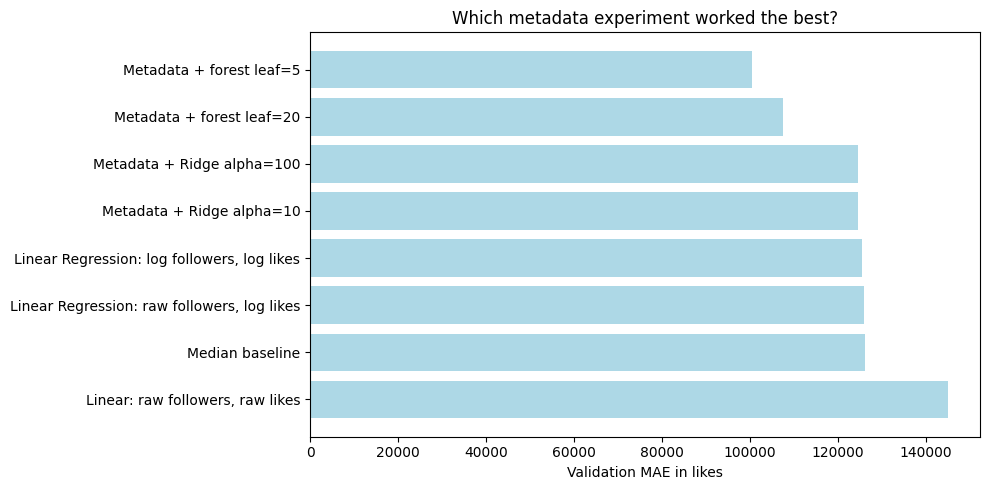

In [19]:
# Comparing the metadata experiments using validation MAE

from pathlib import Path

validation_results = pd.DataFrame(results).sort_values("Validation MAE")
metadata_winner = validation_results.iloc[0]["Model"]

print(validation_results.round(2).to_string(index=False))
print("\nSelected metadata model:", metadata_winner)
# Plotting the results to make the differences easier to see
plt.figure(figsize=(10, 5))
plt.barh(validation_results["Model"], validation_results["Validation MAE"], color="lightblue")
plt.gca().invert_yaxis()
plt.xlabel("Validation MAE in likes") # lower value is better
plt.title("Which metadata experiment worked the best?")
plt.ticklabel_format(axis="x", style="plain")
plt.tight_layout()
plt.show()


## Image Matching and Checking for Duplicates

In [20]:
# Matching each CSV row to its local image file
# Creating a file fingerprint to identify images with exactly the same contents
# Keeping repeated images within a split, but stopping if identical images cross splits

image_lookup = {}
for path in IMAGE_DIR.rglob("*"):
    if path.is_file() and path.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        if path.name in image_lookup:
            raise ValueError("Duplicate filename: " + path.name)
        image_lookup[path.name] = path

matched = df["image_path"].map(lambda path: Path(path).name in image_lookup)
print("Matched posts:", matched.sum(), "of", len(df))
if not matched.all():
    raise ValueError("Some images are missing so inspect the paths before comparing models")

image_df = df.copy()  # Same sorted row order as the metadata experiments.
hashes = []
for path in image_df["image_path"]:
    hashes.append(hashlib.sha256(image_lookup[Path(path).name].read_bytes()).hexdigest())
image_df["image_hash"] = hashes
image_df["split"] = np.select([image_df["t"] < first_cut, image_df["t"] < second_cut],["train", "validation"], default="test")
splits_per_image = image_df.groupby("image_hash")["split"].nunique()
print("Extra exact image copies:", len(hashes) - len(set(hashes)))
print("Repeated groups crossing splits:", (splits_per_image > 1).sum())
if (splits_per_image > 1).any():
    raise ValueError("Identical images are crossing time splits")
image_train = train_df.index.to_numpy()
image_validation = validation_df.index.to_numpy()
image_test = test_df.index.to_numpy()


Matched posts: 3785 of 3785
Extra exact image copies: 8
Repeated groups crossing splits: 0


## CLIP Feature Extraction

In [21]:
# Reusing saved CLIP features only when the image paths, contents and settings match
# This avoids processing the same images again

CACHE_DIR = ROOT / "cache"
CACHE_DIR.mkdir(exist_ok=True)
CACHE_PATH = CACHE_DIR / "clip_embeddings_verified.npz"
CHECKPOINT = "ViT-B/32"
paths = image_df["image_path"].to_numpy(dtype=str)
image_hashes = np.array(hashes)
embeddings = None
if CACHE_PATH.exists():
    with np.load(CACHE_PATH, allow_pickle=False) as cache:
        valid = (
            np.array_equal(cache["image_paths"], paths)
            and np.array_equal(cache["image_hashes"], image_hashes)
            and str(cache["checkpoint"]) == CHECKPOINT
            and bool(cache["normalized"])
        )
        if valid:
            embeddings = cache["embeddings"].copy()
            print("Loaded verified embeddings")
        else:
            print("Cache differs from this dataset so recompute it")
            
# Extracting features if no matching cache was found
if embeddings is None:
    import torch
    import clip
    from PIL import Image
    # Using the NVIDIA GPU when available otherwise use the CPU
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print("Device:", device)
    
    
    # Loading the pretrained CLIP and freeze its weights
    encoder, preprocess = clip.load(CHECKPOINT, device=device)
    encoder.eval()
    for parameter in encoder.parameters():
        parameter.requires_grad = False
    embedding_batches = []
    batch_size = 32
    
    # Processing 32 images at a time to limit memory use
    for start in range(0, len(paths), batch_size):
        tensors = []
        
        # Converting each image to RGB and applying CLIP's required preprocessing
        for path in paths[start:start + batch_size]:
            with Image.open(image_lookup[Path(path).name]) as image:
                tensors.append(preprocess(image.convert("RGB")))
        
        # Extracting 512 features per image without calculating training gradients
        with torch.inference_mode():
            vectors = encoder.encode_image(torch.stack(tensors).to(device)).float()
            vectors = vectors / vectors.norm(dim=1, keepdim=True)
        
        # Moving features to CPU memory so NumPy can store them
        embedding_batches.append(vectors.cpu().numpy())
        print("Encoded", min(start + batch_size, len(paths)), "of", len(paths))
    
    # Combining the batches while keeping the original image order
    embeddings = np.concatenate(embedding_batches)
    
    # Saving features and matching details to avoid repeating extraction
    np.savez_compressed(CACHE_PATH, embeddings=embeddings, image_paths=paths, image_hashes=image_hashes, checkpoint=CHECKPOINT, normalized=True)


# Checking that each image has 512 finite features and a normalized vector
assert embeddings.shape == (len(image_df), 512)
assert np.isfinite(embeddings).all()
assert np.allclose(np.linalg.norm(embeddings, axis=1), 1, atol=0.001)
print("Embedding shape:", embeddings.shape)


Loaded verified embeddings
Embedding shape: (3785, 512)


## Combining Image features and Metadata

In [22]:
# Using the nine visual groups based on the earlier experiments
# Fitting KMeans on training CLIP features and then assigning each image to a group
# Representing the groups with nine indicator columns and combining them with the eight metadata inputs
# Comparing the training likes and followers across groups to describe their differences

embeddings = embeddings.astype(np.float64)
metadata = image_df[feature_columns].to_numpy()
combined_features = np.column_stack([metadata, embeddings])
# Groups are based on image-feature similarity, not on the number of likes
grouping = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=SEED)
grouping.fit(embeddings[image_train])
group_ids = grouping.predict(embeddings)
cluster_features = np.column_stack([metadata, np.eye(N_CLUSTERS)[group_ids]])


training_view = image_df.iloc[image_train].copy()
training_view["visual_group"] = group_ids[image_train]
print(training_view.groupby("visual_group").agg(posts=("likes", "size"), median_likes=("likes", "median"), median_followers=("follower_count_at_t", "median")).round(1).to_string())


              posts  median_likes  median_followers
visual_group                                       
0               343      101540.0        10875012.0
1               218       86693.5        16358117.0
2               129       57044.0         8328997.0
3               180      122172.0         9098863.0
4               228      199279.0        10875012.0
5               346      132716.5         9703914.5
6               260      136501.5         8576575.0
7               312      208806.5         8838196.0
8               255      164141.0        14293070.0


## Comparing Image Based Approaches

In [23]:
# Keeping the five model configurations from the earlier experiments
# Comparing metadata, full CLIP features and CLIP visual groups against a baseline

image_settings = {
    "Median baseline": {"model": DummyRegressor(strategy="median"), "X": metadata, "family": "Baseline", "k": None, "log_target": False}, 
    "Metadata forest leaf=3": {"model": RandomForestRegressor(n_estimators=200, min_samples_leaf=3, random_state=SEED, n_jobs=2), "X": metadata, "family": "Metadata", "k": None, "log_target": True},
    "CLIP only Ridge alpha=1000": {"model": make_pipeline(StandardScaler(), Ridge(alpha=1000)), "X": embeddings, "family": "CLIP only", "k": None, "log_target": True},
    "Metadata + CLIP forest leaf=5": {"model": RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=SEED, n_jobs=2),"X": combined_features, "family": "Metadata + CLIP", "k": None, "log_target": True},
    "Metadata + CLIP clusters k=9 forest leaf=5": {"model": RandomForestRegressor(n_estimators=200, min_samples_leaf=5,random_state=SEED, n_jobs=2),"X": cluster_features, "family": "Metadata + CLIP clusters", "k": 9, "log_target": True}
}


In [24]:
# Training each configuration on the training posts and scoring it on validation posts.
# Converting log predictions back into likes before calculating MAE

# Returning predictions in like counts and preventing negative values
def predict_like_counts(model, X, log_target):
    prediction = model.predict(X)
    if log_target:
        prediction = np.expm1(prediction)
    return np.maximum(prediction, 0)

image_y = image_df["likes"].to_numpy()
image_rows = []
for name, settings in image_settings.items():
    model = clone(settings["model"])
    target = np.log1p(image_y) if settings["log_target"] else image_y
    model.fit(settings["X"][image_train], target[image_train])
    prediction = predict_like_counts(model, settings["X"][image_validation], settings["log_target"])
    mae = mean_absolute_error(image_y[image_validation], prediction)
    image_rows.append({"Family": settings["family"], "Model": name, "Validation MAE": mae})

image_validation_results = pd.DataFrame(image_rows).sort_values("Validation MAE")
selected_name = image_validation_results.iloc[0]["Model"]

# Showing only the best setting from each family
validation_summary = image_validation_results.drop_duplicates("Family").copy()
validation_summary["Model"] = validation_summary["Model"].str.replace("Metadata + groups", "Metadata + CLIP clusters", regex=False)
print(validation_summary[["Model", "Validation MAE"]].round(2).to_string(index=False))
print("Model with best performance in the validation comparison:", selected_name.replace("Metadata + groups", "Metadata + CLIP clusters"))


                                     Model  Validation MAE
Metadata + CLIP clusters k=9 forest leaf=5        96131.57
                    Metadata forest leaf=3       101592.11
             Metadata + CLIP forest leaf=5       107687.15
                CLIP only Ridge alpha=1000       109303.83
                           Median baseline       126160.22
Model with best performance in the validation comparison: Metadata + CLIP clusters k=9 forest leaf=5


## Final test Evaluation

In [25]:
# Calculating average error, sensitivity to large errors and how well the predictions rank the posts


def evaluation_metrics(actual, prediction):
    correlation = np.nan
    if np.ptp(prediction) > 0:
        correlation = pd.Series(actual).rank().corr(pd.Series(prediction).rank())
    return {"MAE": mean_absolute_error(actual, prediction),"RMSE": np.sqrt(mean_squared_error(actual, prediction)), "RMSLE": np.sqrt(mean_squared_log_error(actual, prediction)), "R2": r2_score(actual, prediction), "Spearman": correlation
    }

development_indices = np.concatenate([image_train, image_validation])


# Keeping the validation-selected configuration fixed
# Training fresh models using training and validation posts together
# Refitting KMeans on these development posts for the cluster-based model
# Evaluating all approaches on the same later test posts for comparison

family_winners = image_validation_results
test_rows = []
test_predictions = {}
final_models = {}
final_groupings = {}
for name in family_winners["Model"]:
    settings = image_settings[name]
    matrix = settings["X"]
    if settings["k"] is not None:
        k = settings["k"]
        grouping = KMeans(n_clusters=k, n_init=10, random_state=SEED)
        grouping.fit(embeddings[development_indices])
        matrix = np.column_stack([metadata, np.eye(k)[grouping.predict(embeddings)]])
        final_groupings[name] = grouping
    model = clone(settings["model"])
    target = np.log1p(image_y) if settings["log_target"] else image_y
    model.fit(matrix[development_indices], target[development_indices])
    prediction = predict_like_counts(model, matrix[image_test], settings["log_target"])
    final_models[name] = model
    test_predictions[name] = prediction
    test_rows.append({"Family": settings["family"], "Model": name,**evaluation_metrics(image_y[image_test], prediction)})

# Reporting the test performance while keeping the model choice made on validation


test_results = pd.DataFrame(test_rows).sort_values("MAE")
selected_predictions = test_predictions[selected_name]
test_actual = image_y[image_test]
test_posts = image_df.iloc[image_test].copy()
selected_test_mae = mean_absolute_error(test_actual, selected_predictions)
baseline_test_mae = test_results.loc[test_results["Family"] == "Baseline", "MAE"].iloc[0]
mae_reduction = 100 * (1 - selected_test_mae / baseline_test_mae)
cohort_label = "All matched posts"
print("Model with best performance selected using validation:", selected_name.replace("Metadata + groups", "Metadata + CLIP clusters"))
test_display = test_results[["Model", "MAE", "R2"]].copy()
test_display["Model"] = test_display["Model"].str.replace("Metadata + groups", "Metadata + CLIP clusters", regex=False)
print(test_display.round(3).to_string(index=False))


Model with best performance selected using validation: Metadata + CLIP clusters k=9 forest leaf=5
                                     Model        MAE     R2
Metadata + CLIP clusters k=9 forest leaf=5  67674.908  0.656
                    Metadata forest leaf=3  76064.479  0.531
                CLIP only Ridge alpha=1000  97501.814  0.251
             Metadata + CLIP forest leaf=5 104358.148  0.183
                           Median baseline 124613.356 -0.014


## Visualizing Predictions and Inspecting Errors

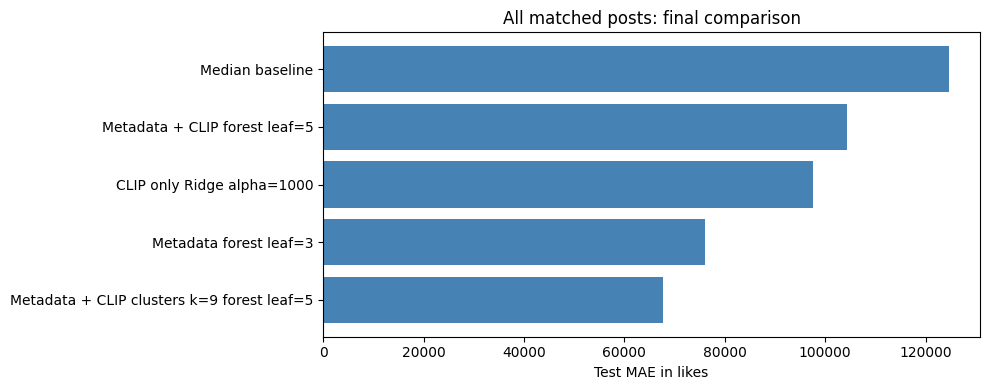

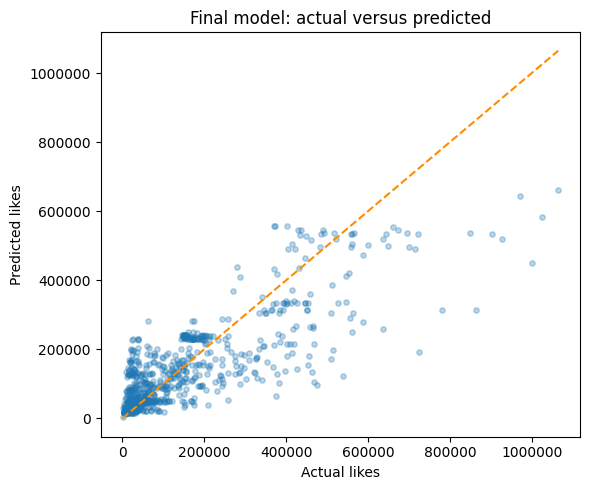

In [26]:
# Comparing the test MAE across the approaches and lower values mean smaller average mistakes
# Plotting actual likes against predicted likes for the selected model
# Points close to the diagonal line represent more accurate predictions


plt.figure(figsize=(10, 4))
plt.barh(test_results["Model"].str.replace("Metadata + groups", "Metadata + CLIP clusters", regex=False), test_results["MAE"], color="steelblue")
plt.xlabel("Test MAE in likes") #lower the value better the results
plt.title(cohort_label + ": final comparison")
plt.ticklabel_format(axis="x", style="plain")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(test_actual, selected_predictions, alpha=0.3, s=15)
largest_count = max(test_actual.max(), selected_predictions.max())
plt.plot([0, largest_count], [0, largest_count], "--", color="darkorange")
plt.xlabel("Actual likes")
plt.ylabel("Predicted likes")
plt.title("Final model: actual versus predicted")
plt.ticklabel_format(axis="both", style="plain")
plt.tight_layout()
plt.show()


In [27]:
prediction_check = test_posts[["image_path", "likes", "follower_count_at_t", "post_time"]].copy()
prediction_check["predicted_likes"] = selected_predictions
prediction_check["absolute_error"] = abs(prediction_check["likes"] - selected_predictions)

# Showing a middle-range post predicted within 10% of its observed likes
# This is a selected example, so it does not represent every prediction


low, high = prediction_check["likes"].quantile([0.25, 0.75])
small_error = prediction_check["absolute_error"] / prediction_check["likes"] <= 0.10
examples = prediction_check[prediction_check["likes"].between(low, high) & small_error]
print("Successful test example:")
if len(examples):
    print(examples.head(1)[["image_path", "likes", "predicted_likes", "absolute_error"]].round(0).to_string(index=False))
else:
    print("No example met the 10% error and middle-range criteria.")
print("\nLargest error:")

# Inspecting the largest mistake to understand where the model struggles

print(prediction_check.nlargest(1, "absolute_error").round(0).to_string(index=False))
prediction_check.to_csv(RESULTS_DIR / "test_predictions.csv", index=False)

like_groups = pd.qcut(prediction_check["likes"], 4, duplicates="drop")
error_by_group = prediction_check.groupby(like_groups, observed=True)["absolute_error"].agg(["count", "mean"])
print("\nMean absolute error by observed-like quartile:")
print(error_by_group.round(1).to_string())


Successful test example:
                 image_path  likes  predicted_likes  absolute_error
../Data/insta_data/8192.jpg 107815         114786.0          6971.0

Largest error:
                image_path   likes  follower_count_at_t                 post_time  predicted_likes  absolute_error
../Data/insta_data/413.jpg 1001243             40220549 2020-06-29 04:24:02+00:00         450300.0        550943.0

Mean absolute error by observed-like quartile:
                       count      mean
likes                                 
(2178.999, 32645.0]      190   47102.5
(32645.0, 77120.0]       189   33717.2
(77120.0, 194094.0]      189   49670.4
(194094.0, 1064782.0]    189  140318.4


## Likes Evaluation (Low, Medium, High)

In [28]:
#Defining low, medium and high likes using thirds of the training distribution
# applying the same boundaries to actual and predicted test likes
# Measuring how often the predicted band matches the actual band

from sklearn.metrics import accuracy_score, f1_score
segment_edges = np.quantile(image_y[image_train], [1/3, 2/3])
segment_names = ["Low likes", "Medium likes", "High likes"]
actual_segments = np.searchsorted(segment_edges, test_actual, side="left")
predicted_segments = np.searchsorted(segment_edges, selected_predictions, side="left")
print("Training boundaries:", segment_edges)
print("Segment accuracy:", round(accuracy_score(actual_segments, predicted_segments), 3))
print("Macro F1:", round(f1_score(actual_segments, predicted_segments,labels=[0, 1, 2], average="macro", zero_division=0), 3))


Training boundaries: [ 82844.33333333 207133.33333333]
Segment accuracy: 0.647
Macro F1: 0.622


## Final Summary

In [29]:
# Summarizing the selected model, test MAE and improvement over the baseline


print("Final model:", selected_name.replace("Metadata + groups", "Metadata + CLIP clusters"))
print("Test posts:", len(test_actual))
print("Test MAE:", round(selected_test_mae))
print("MAE reduction versus baseline:", round(mae_reduction, 1), "%")


Final model: Metadata + CLIP clusters k=9 forest leaf=5
Test posts: 757
Test MAE: 67675
MAE reduction versus baseline: 45.7 %
